# Replica Parameter Uncertainty

Summary notebook for replica result CSV files under `../Fits/replica_data/`.
It maps `param_i` columns back to the active card parameter names, supports both
legacy and current replica schemas, and reports robust central intervals for the
stored replica refits.


In [1]:
import csv
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")


In [2]:
fit_name = "Final_old"
replica_results_path = Path("../Fits/replica_data/replica_0325.csv")
pairplot_mode = "free"  # "free" or "all"
use_success_only = True
show_success_failure_overlay = True
export_correlation_pdf = True
correlation_plot_pdf_path = Path("Plots/parameter_correlation.pdf")


In [3]:
card_path = Path("../Cards") / f"{fit_name}.jl"
card_text = card_path.read_text(encoding="utf-8")

struct_match = re.search(r"struct\s+Params_Struct(.*?)end", card_text, re.S)
if struct_match is None:
    raise ValueError(f"Could not find Params_Struct in {card_path}")

param_names = re.findall(
    r"([A-Za-z_][A-Za-z0-9_]*)\s*::\s*Float32",
    struct_match.group(1),
)

def latex_param_name(name):
    special = {
        "logx0": r"$\log x_0$",
        "sigx": r"$\sigma_x$",
        "amp": r"$A_{\rm NP}$",
        "BNP": r"$B_{\rm NP}$",
    }
    if name in special:
        return special[name]

    match = re.fullmatch(r"([A-Za-z]+)(\d+)", name)
    if match:
        base, idx = match.groups()
        if base == "lambda":
            return rf"$\lambda_{{{idx}}}$"
        return rf"${base}_{{{idx}}}$"

    return rf"${name}$"

latex_param_labels = {name: latex_param_name(name) for name in param_names}
param_columns = [f"param_{i}" for i in range(len(param_names))]

init_matches = re.findall(r"(?ms)^\s*initial_params\s*=\s*\[([^\]]*)\]", card_text)
if not init_matches:
    raise ValueError(f"Could not find initial_params in {card_path}")
initial_params = np.asarray(
    [float(x) for x in re.findall(r"-?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?", init_matches[-1])],
    dtype=float,
)

frozen_match = re.search(r"frozen_indices\s*=\s*\[([^\]]*)\]", card_text)
frozen_idx = (
    np.asarray([int(x) for x in re.findall(r"-?\d+", frozen_match.group(1))], dtype=int)
    if frozen_match
    else np.asarray([], dtype=int)
)
frozen_set = set(frozen_idx.tolist())

param_info_df = pd.DataFrame(
    {
        "index": np.arange(len(param_names), dtype=int),
        "parameter": param_names,
        "latex_label": [latex_param_labels[name] for name in param_names],
        "initial_value": initial_params[: len(param_names)],
        "frozen": [i in frozen_set for i in range(len(param_names))],
    }
)
display(param_info_df)


,index,parameter,latex_label,initial_value,frozen
0,0,lambda1,$\lambda_{1}$,0.023656,False
1,1,lambda2,$\lambda_{2}$,1.054291,False
2,2,lambda3,$\lambda_{3}$,-2.354365,False
3,3,logx0,$\log x_0$,-5.207703,False
4,4,sigx,$\sigma_x$,1.103274,False
5,5,amp,$A_{\rm NP}$,-0.431106,False
6,6,BNP,$B_{\rm NP}$,1.494665,False
7,7,c0,$c_{0}$,0.070013,False
8,8,c1,$c_{1}$,0.027637,False


In [4]:
def load_replica_results(path):
    required_columns = [
        "replica_id",
        "success",
        "nfev",
        "best_chi2dN",
        *param_columns,
    ]

    df = pd.read_csv(path)
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")

    if "pdf_replica_id" not in df.columns:
        df["pdf_replica_id"] = pd.Series(pd.array([pd.NA] * len(df), dtype="string"), index=df.index)
    else:
        df["pdf_replica_id"] = df["pdf_replica_id"].astype("string")

    if "pdf_shift_seed" not in df.columns:
        df["pdf_shift_seed"] = pd.Series(pd.array([pd.NA] * len(df), dtype="Int64"), index=df.index)
    else:
        df["pdf_shift_seed"] = pd.to_numeric(df["pdf_shift_seed"], errors="coerce").astype("Int64")

    numeric_columns = ["replica_id", "success", "nfev", "best_chi2dN", *param_columns]
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=required_columns).copy()
    df["replica_id"] = df["replica_id"].astype(int)
    df["success"] = df["success"].astype("Int64")
    df["nfev"] = df["nfev"].astype("Int64")

    bad_success_values = sorted(set(df["success"].dropna().astype(int)) - {0, 1})
    if bad_success_values:
        raise ValueError(
            f"Parsed success column contains non-binary values {bad_success_values}; CSV schema may be misaligned"
        )

    for col, name in zip(param_columns, param_names):
        df[name] = df[col]

    return df.sort_values("replica_id").reset_index(drop=True)

replica_results_all_df = load_replica_results(replica_results_path)
replica_results_df = replica_results_all_df.copy()
if use_success_only:
    replica_results_df = replica_results_df[replica_results_df["success"] == 1].reset_index(drop=True)
print(f"Loaded {len(replica_results_df)} replica refits from {replica_results_path}")
print(f"use_success_only = {use_success_only}")
print("success counts in source file:")
display(replica_results_all_df["success"].value_counts(dropna=False).sort_index().rename("count").to_frame())
duplicate_counts = replica_results_all_df["replica_id"].value_counts()
duplicate_ids = duplicate_counts[duplicate_counts > 1]
if not duplicate_ids.empty:
    print("warning: duplicate replica_id values found in source file")
    display(duplicate_ids.rename("count").to_frame())

display(replica_results_df[["replica_id", "pdf_replica_id", "pdf_shift_seed", "success", "nfev", "best_chi2dN", *param_columns]].head())


ValueError: ..\Bayesian Analysis\bayesian parameters\bayesian_parameters.csv is missing required columns: ['replica_id', 'success', 'nfev', 'best_chi2dN', 'param_0', 'param_1', 'param_2', 'param_3', 'param_4', 'param_5', 'param_6', 'param_7', 'param_8']

In [ ]:
alpha = 0.15865

def summarize_columns(df, columns):
    summary = pd.DataFrame(index=columns)
    summary["mean"] = df[columns].mean()
    summary["std"] = df[columns].std(ddof=1)
    summary["q_lo"] = df[columns].quantile(alpha)
    summary["median"] = df[columns].quantile(0.5)
    summary["q_hi"] = df[columns].quantile(1.0 - alpha)
    summary["minus"] = np.nan
    summary["plus"] = np.nan
    return summary

def format_sig(value, sig):
    from decimal import Decimal

    value = float(value)
    if value == 0:
        return "0." + "0" * (sig - 1)

    decimal_value = Decimal(str(value))
    exponent = abs(decimal_value).adjusted()
    places = sig - exponent - 1
    rounded = decimal_value.quantize(Decimal(f"1e{-places}"))
    rounded_exponent = abs(rounded).adjusted()
    places = sig - rounded_exponent - 1
    rounded = decimal_value.quantize(Decimal(f"1e{-places}"))

    if places > 0:
        return format(rounded, f".{places}f")
    if places == 0:
        return format(rounded, ".0f")
    return format(rounded, "f")

param_summary = summarize_columns(replica_results_df, param_columns)
param_summary.insert(0, "parameter", param_names)
param_summary.insert(1, "initial_value", initial_params[: len(param_names)])
param_summary.insert(2, "frozen", [i in frozen_set for i in range(len(param_names))])
param_summary["minus"] = param_summary["mean"] - param_summary["q_lo"]
param_summary["plus"] = param_summary["q_hi"] - param_summary["mean"]
display(param_summary)

paper_param_summary = param_summary.set_index("parameter", drop=False).copy()
logx0_row = paper_param_summary.loc["logx0"]
x0_initial = np.exp(logx0_row["initial_value"])
x0_mean = np.exp(logx0_row["mean"])
x0_q_lo = np.exp(logx0_row["q_lo"])
x0_median = np.exp(logx0_row["median"])
x0_q_hi = np.exp(logx0_row["q_hi"])
x0_minus = x0_mean - x0_q_lo
x0_plus = x0_q_hi - x0_mean
paper_param_summary.loc["x0"] = {
    "parameter": "x0",
    "initial_value": x0_initial,
    "frozen": bool(logx0_row["frozen"]),
    "mean": x0_mean,
    "std": np.nan,
    "q_lo": x0_q_lo,
    "median": x0_median,
    "q_hi": x0_q_hi,
    "minus": x0_minus,
    "plus": x0_plus,
}

paper_order = ["lambda1", "lambda2", "lambda3", "x0", "sigx", "amp", "BNP", "c0", "c1"]
paper_labels = {
    "c0": r"$c_0$",
    "c1": r"$c_1$",
    "BNP": r"$B_{\rm NP}$",
    "lambda1": r"$\lambda_1$",
    "lambda2": r"$\lambda_2$",
    "lambda3": r"$\lambda_3$",
    "amp": r"$A_{\rm NP}$",
    "x0": r"$x_0$",
    "sigx": r"$\sigma_x$",
}
paper_param_summary = paper_param_summary.loc[paper_order].copy()
paper_param_summary["latex_label"] = [paper_labels[name] for name in paper_param_summary["parameter"]]
minus_glyph = "\N{MINUS SIGN}"
paper_param_summary["display_central"] = paper_param_summary["mean"].map(lambda value: format_sig(value, 3))
paper_param_summary["display_minus"] = paper_param_summary["minus"].map(lambda value: format_sig(value, 2))
paper_param_summary["display_plus"] = paper_param_summary["plus"].map(lambda value: format_sig(value, 2))
paper_param_summary["display_entry"] = paper_param_summary.apply(
    lambda row: f"{row['display_central']}^(+{row['display_plus']})_({minus_glyph}{row['display_minus']})",
    axis=1,
)
paper_param_summary["latex_entry"] = paper_param_summary.apply(
    lambda row: rf"{row['display_central']}^{{+{row['display_plus']}}}_{{-{row['display_minus']}}}",
    axis=1,
)
display(paper_param_summary[["latex_label", "display_central", "display_minus", "display_plus", "display_entry", "latex_entry"]])

display(replica_results_df[["best_chi2dN", "nfev"]].describe())


,parameter,initial_value,frozen,mean,std,q_lo,median,q_hi,minus,plus
param_0,lambda1,0.023656,False,0.016432,0.042623,-0.027538,0.014795,0.047573,0.043970,0.031141
param_1,lambda2,1.054291,False,1.032020,0.174994,0.850787,1.025201,1.173831,0.181233,0.141811
param_2,lambda3,-2.354365,False,-2.363244,0.467357,-2.759044,-2.339030,-1.889532,0.395799,0.473712
param_3,logx0,-5.207703,False,-5.168420,0.334830,-5.492819,-5.205828,-4.878932,0.324399,0.289488
param_4,sigx,1.103274,False,1.097647,0.141003,0.984371,1.111583,1.229517,0.113276,0.131870
param_5,amp,-0.431106,False,-0.472722,0.171777,-0.578894,-0.451565,-0.320976,0.106173,0.151746
param_6,BNP,1.494665,False,1.528641,0.152062,1.395102,1.522251,1.666491,0.133539,0.137850
param_7,c0,0.070013,False,0.069849,0.006035,0.063780,0.069928,0.075487,0.006069,0.005639
param_8,c1,0.027637,False,0.028185,0.007953,0.020899,0.027378,0.036010,0.007286,0.007825


,latex_label,display_central,display_minus,display_plus,latex_entry
parameter,,,,,
lambda1,$\lambda_1$,0.0164,0.044,0.031,0.0164^{+0.031}_{-0.044}
lambda2,$\lambda_2$,1.03,0.18,0.14,1.03^{+0.14}_{-0.18}
lambda3,$\lambda_3$,-2.36,0.40,0.47,-2.36^{+0.47}_{-0.40}
x0,$x_0$,0.00569,0.0016,0.0019,0.00569^{+0.0019}_{-0.0016}
sigx,$\sigma_x$,1.10,0.11,0.13,1.10^{+0.13}_{-0.11}
amp,$A_{\rm NP}$,-0.473,0.11,0.15,-0.473^{+0.15}_{-0.11}
BNP,$B_{\rm NP}$,1.53,0.13,0.14,1.53^{+0.14}_{-0.13}
c0,$c_0$,0.0698,0.0061,0.0056,0.0698^{+0.0056}_{-0.0061}
c1,$c_1$,0.0282,0.0073,0.0078,0.0282^{+0.0078}_{-0.0073}


,best_chi2dN,nfev
count,80.000000,80.0
mean,1.912162,1545.6625
std,0.148708,96.179414
min,1.530586,989.0
25%,1.807420,1533.0
50%,1.906235,1568.0
75%,1.989457,1589.25
max,2.290916,1620.0


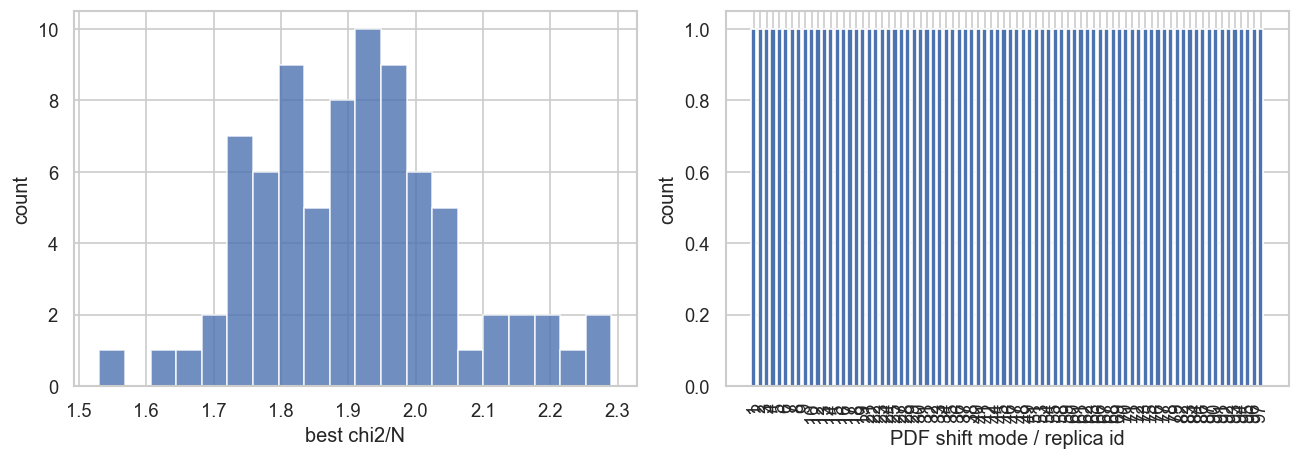

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(replica_results_df["best_chi2dN"], bins=20, alpha=0.8)
axes[0].set_xlabel("best chi2/N")
axes[0].set_ylabel("count")

pdf_labels = replica_results_df["pdf_replica_id"].dropna().astype(str)
if pdf_labels.empty:
    axes[1].text(0.5, 0.5, "no pdf_replica_id data", ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_xlabel("PDF shift mode / replica id")
else:
    if pdf_labels.str.fullmatch(r"-?\d+").all():
        pdf_counts = pdf_labels.astype(int).value_counts().sort_index()
    else:
        pdf_counts = pdf_labels.value_counts().sort_index()
    axes[1].bar(pdf_counts.index.astype(str), pdf_counts.values)
    axes[1].set_xlabel("PDF shift mode / replica id")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


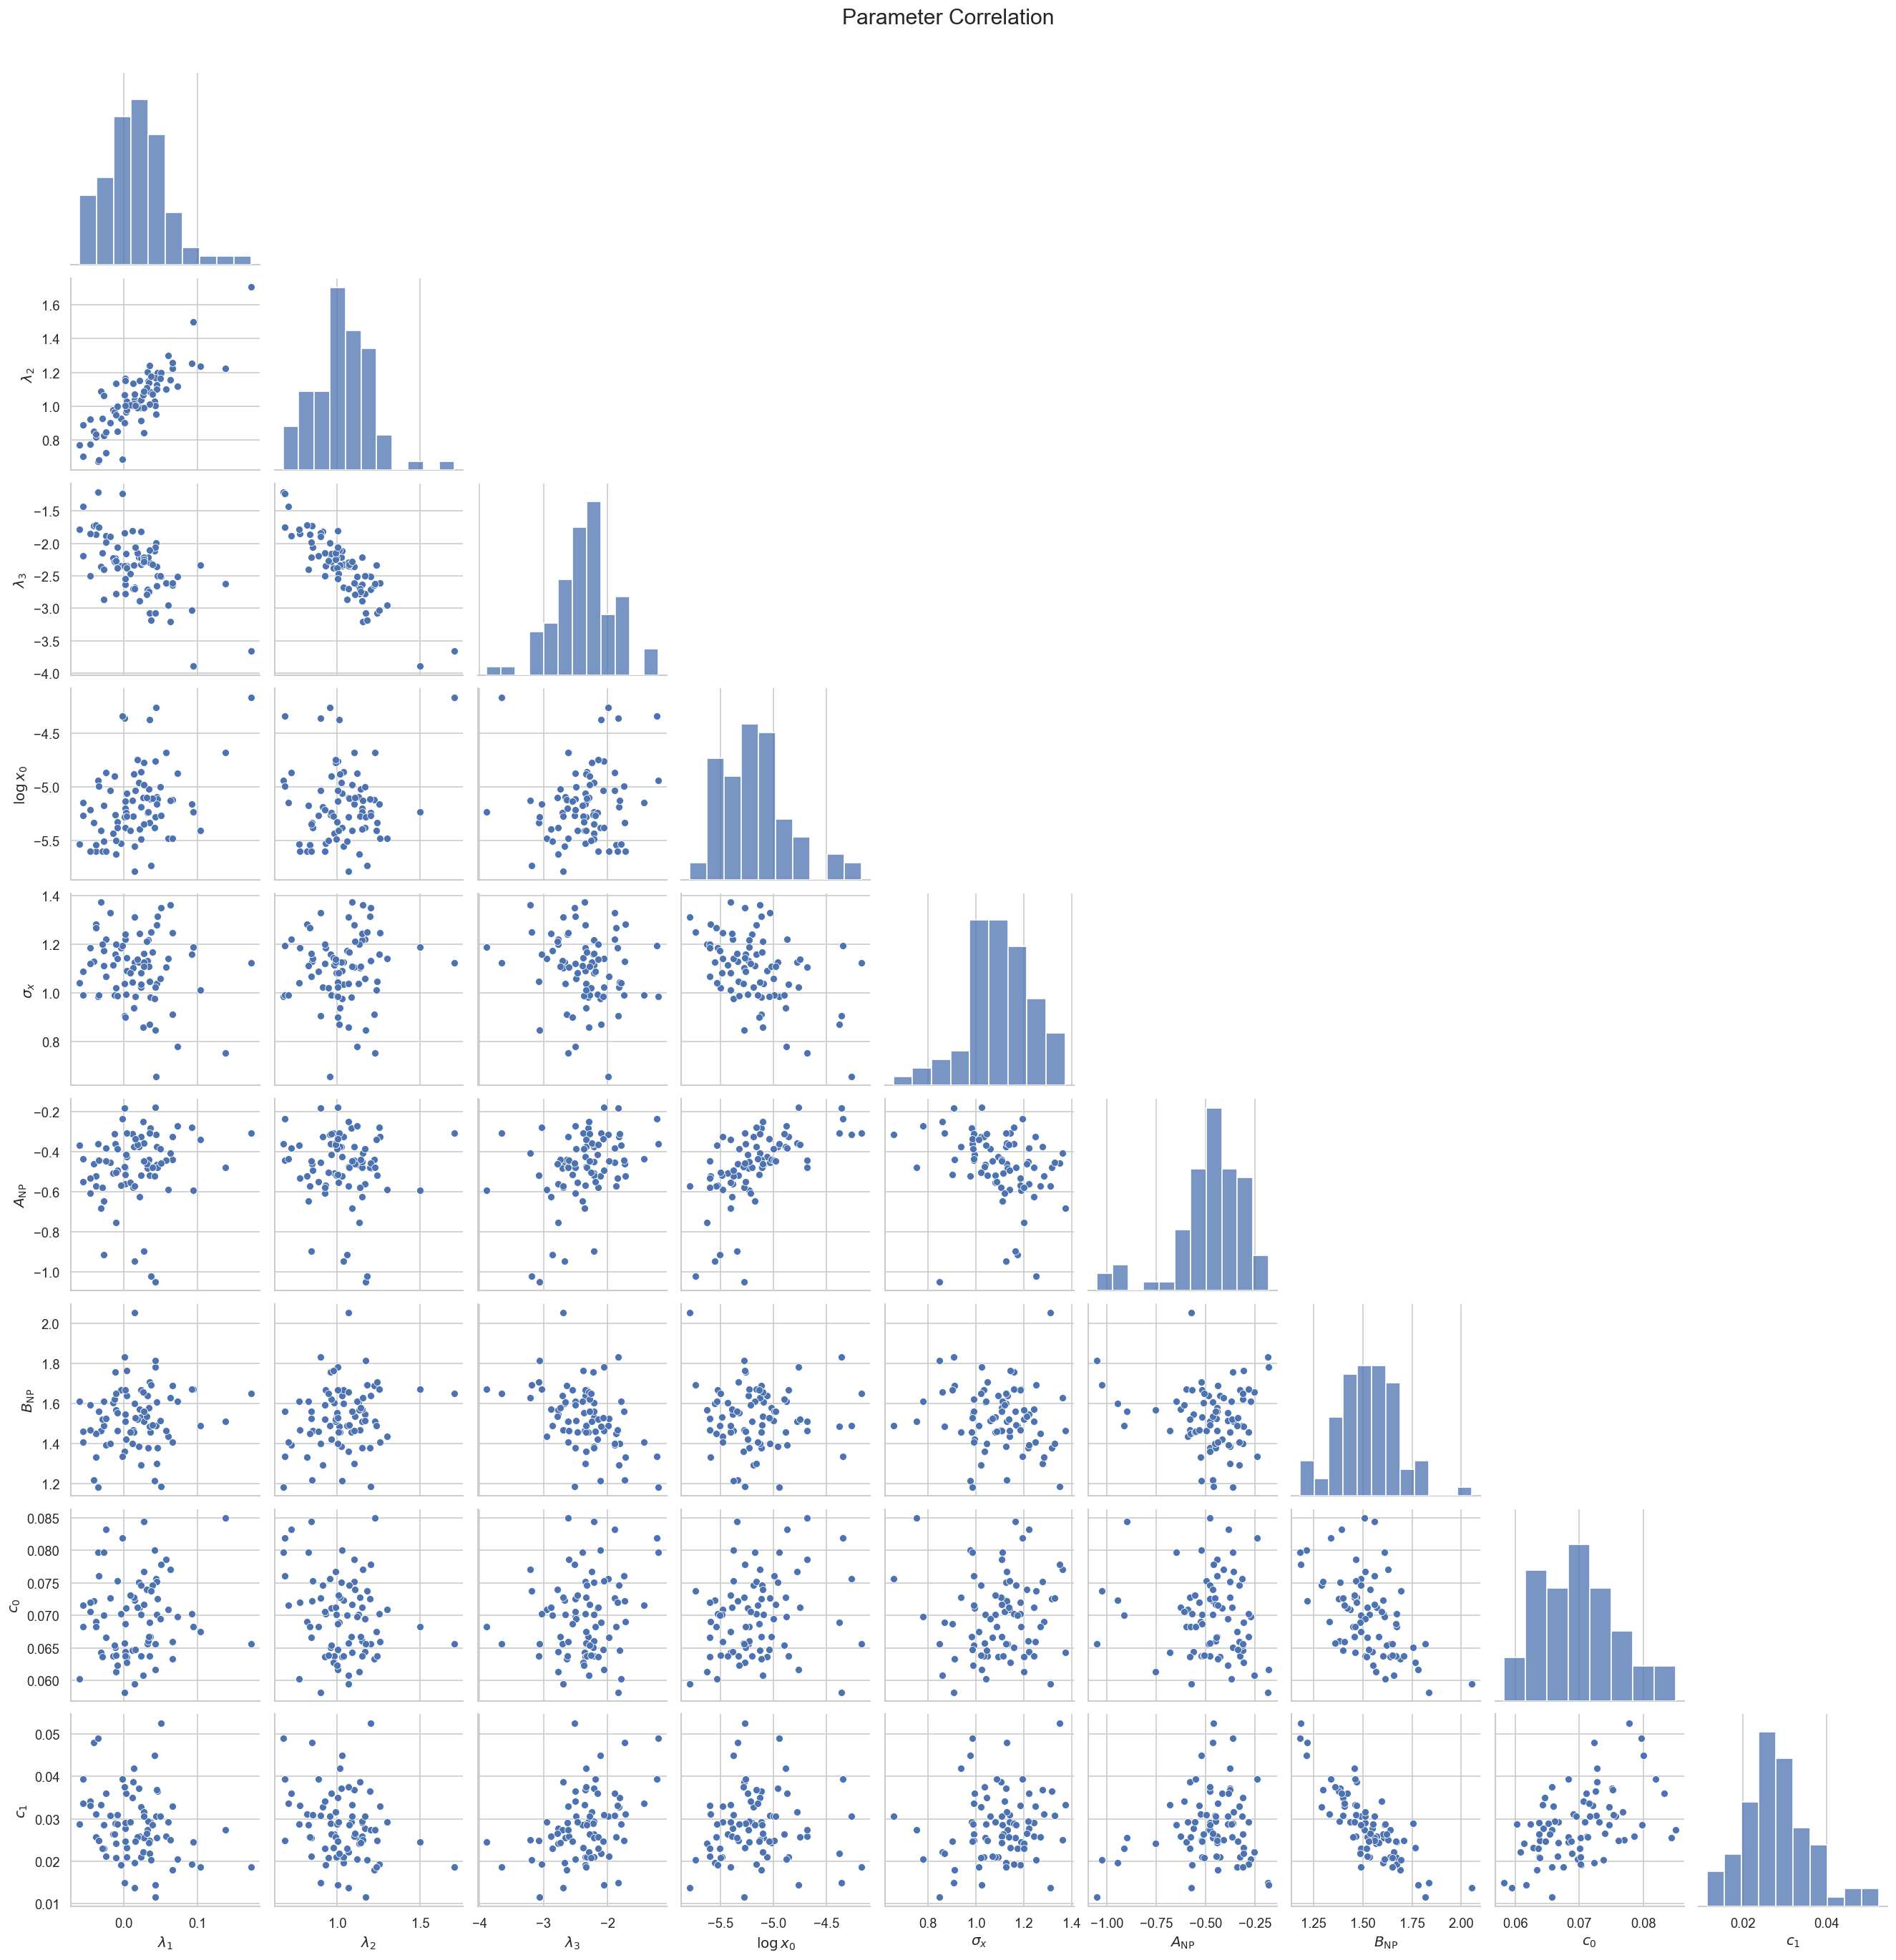

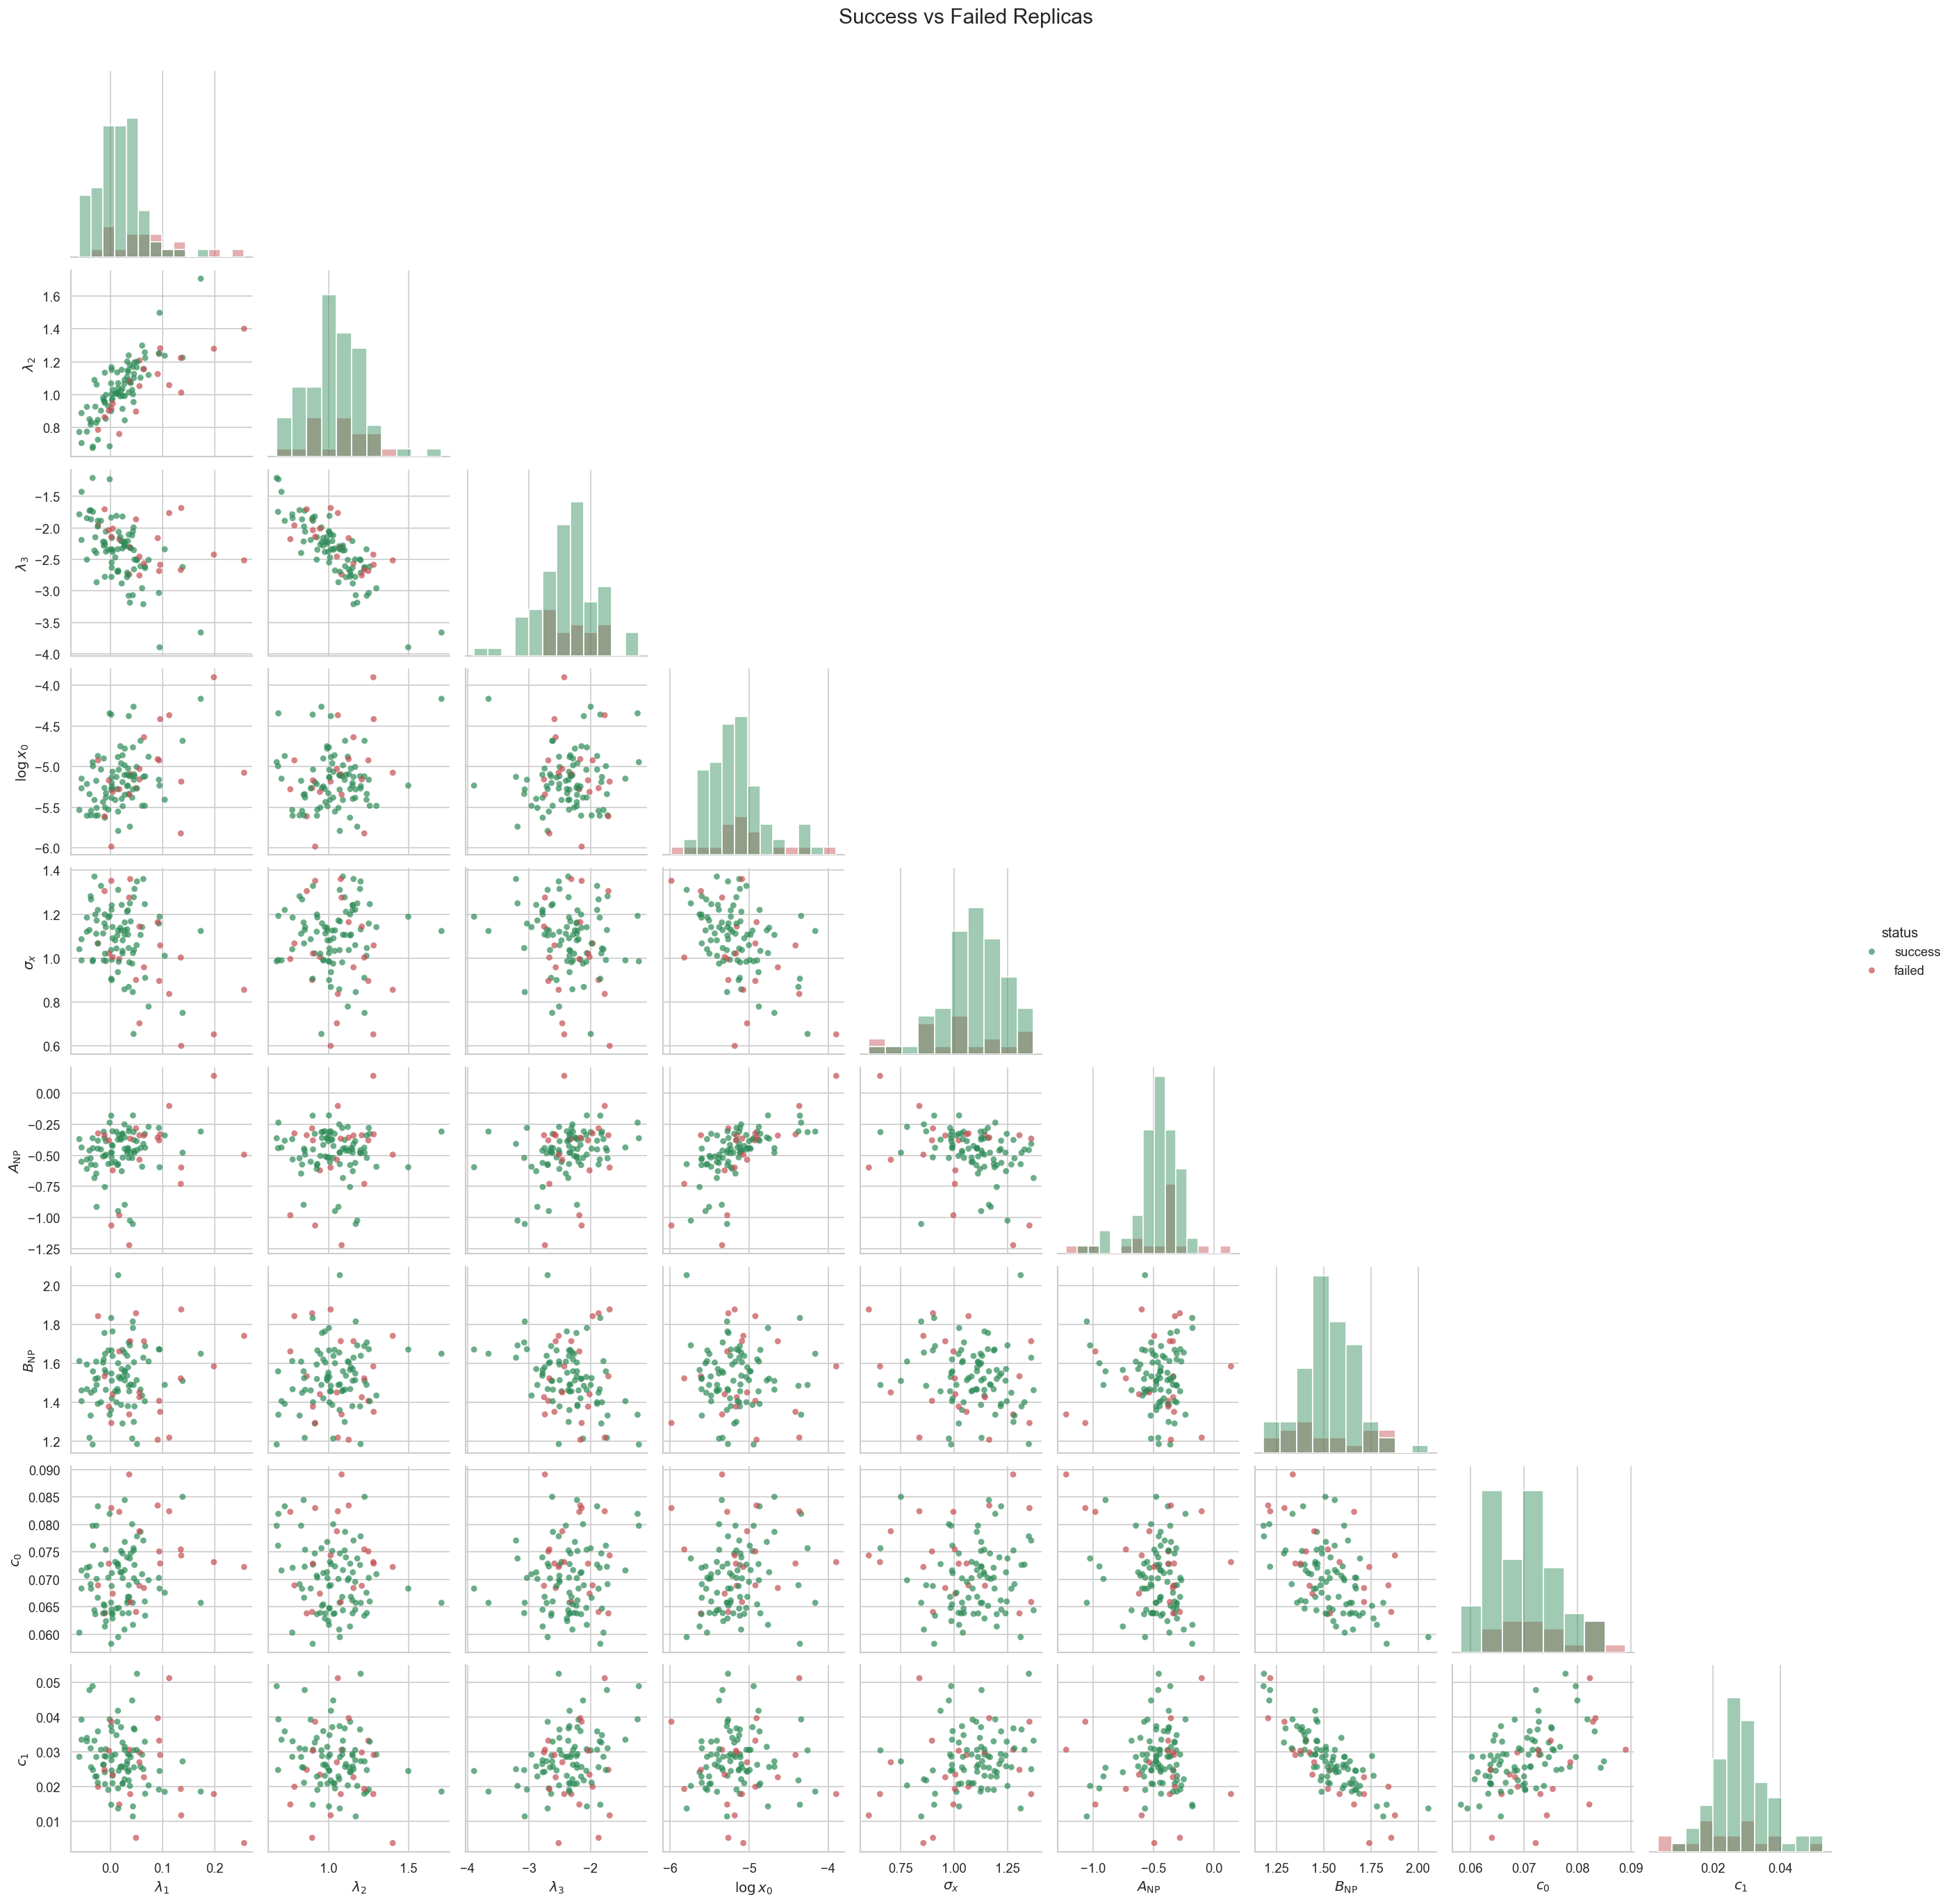

In [ ]:
if pairplot_mode == "all":
    pairplot_columns = param_names
else:
    pairplot_columns = [name for i, name in enumerate(param_names) if i not in frozen_set]

plot_df = replica_results_df[pairplot_columns].copy().rename(columns=latex_param_labels)
g = sns.pairplot(plot_df, corner=True, diag_kind="hist")
g.figure.suptitle("Parameter Correlation", y=1.02, fontsize=18)
plt.show()

if show_success_failure_overlay:
    overlay_df = replica_results_all_df[pairplot_columns + ["success"]].copy()
    overlay_df["status"] = overlay_df["success"].map({1: "success", 0: "failed"}).fillna("other")
    overlay_df = overlay_df.drop(columns=["success"]).rename(columns=latex_param_labels)
    palette = {"success": "#2E8B57", "failed": "#C44E52", "other": "#7F7F7F"}
    g = sns.pairplot(
        overlay_df,
        vars=[latex_param_labels[name] for name in pairplot_columns],
        hue="status",
        corner=True,
        diag_kind="hist",
        palette=palette,
        plot_kws={"alpha": 0.7, "s": 28, "edgecolor": "none"},
        diag_kws={"alpha": 0.45, "common_norm": False},
    )
    g.figure.suptitle("Success vs Failed Replicas", y=1.02, fontsize=18)
    plt.show()


,$\lambda_{1}$,$\lambda_{2}$,$\lambda_{3}$,$x_0$,$\sigma_x$,$A_{\rm NP}$,$B_{\rm NP}$,$c_{0}$,$c_{1}$
$\lambda_{1}$,1.000,0.816,-0.612,0.366,-0.170,0.166,0.150,0.114,-0.271
$\lambda_{2}$,0.816,1.000,-0.867,0.062,0.079,-0.080,0.241,-0.232,-0.269
$\lambda_{3}$,-0.612,-0.867,1.000,0.126,-0.169,0.374,-0.445,0.162,0.388
$x_0$,0.366,0.062,0.126,1.000,-0.438,0.583,-0.032,0.224,0.027
$\sigma_x$,-0.170,0.079,-0.169,-0.438,1.000,-0.276,-0.139,0.060,0.175
$A_{\rm NP}$,0.166,-0.080,0.374,0.583,-0.276,1.000,-0.115,-0.131,0.140
$B_{\rm NP}$,0.150,0.241,-0.445,-0.032,-0.139,-0.115,1.000,-0.531,-0.825
$c_{0}$,0.114,-0.232,0.162,0.224,0.060,-0.131,-0.531,1.000,0.484
$c_{1}$,-0.271,-0.269,0.388,0.027,0.175,0.140,-0.825,0.484,1.000


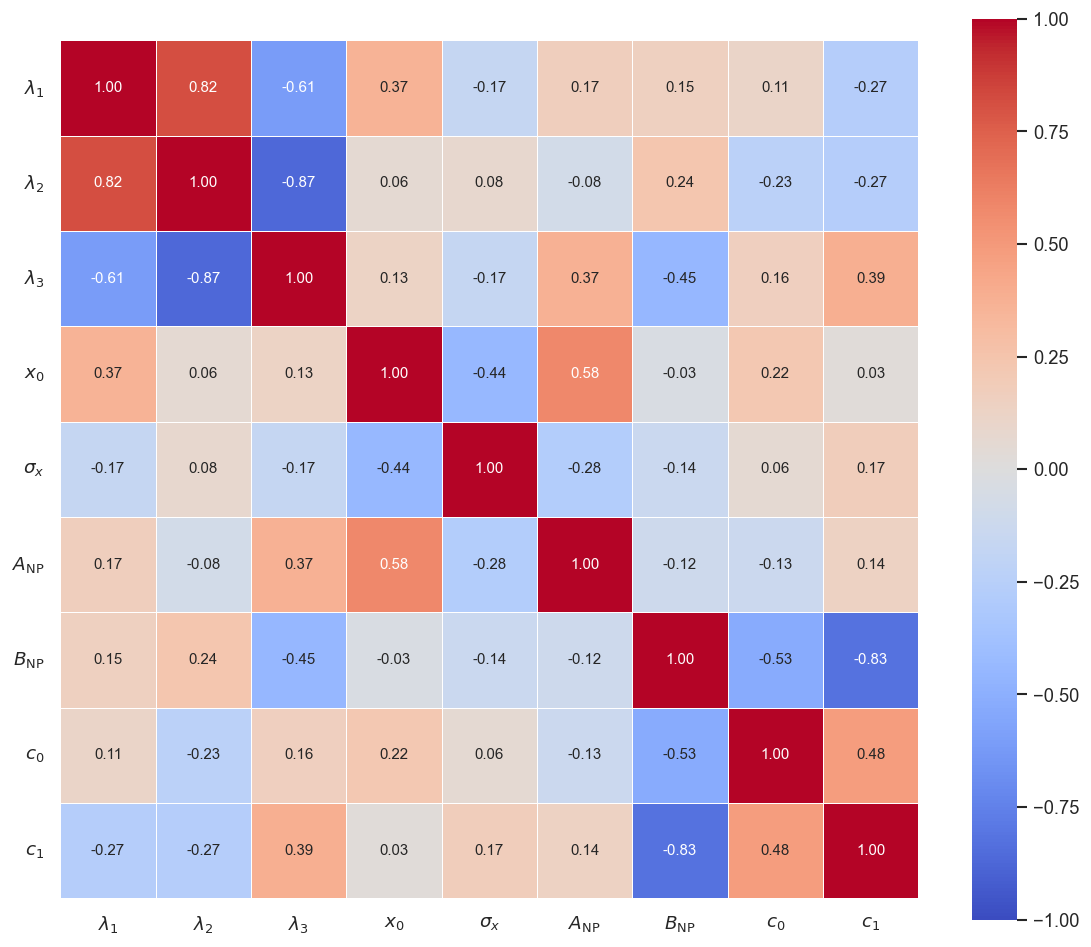

,param_a,param_b,corr,abs_corr
8,$\lambda_{2}$,$\lambda_{3}$,-0.867254,0.867254
34,$B_{\rm NP}$,$c_{1}$,-0.825415,0.825415
0,$\lambda_{1}$,$\lambda_{2}$,0.815613,0.815613
1,$\lambda_{1}$,$\lambda_{3}$,-0.612226,0.612226
22,$x_0$,$A_{\rm NP}$,0.582702,0.582702
33,$B_{\rm NP}$,$c_{0}$,-0.531087,0.531087
35,$c_{0}$,$c_{1}$,0.483831,0.483831
18,$\lambda_{3}$,$B_{\rm NP}$,-0.445382,0.445382
21,$x_0$,$\sigma_x$,-0.437791,0.437791
20,$\lambda_{3}$,$c_{1}$,0.388152,0.388152


,quantity,value
0,n_parameters,9.000000
1,max_abs_corr_offdiag,0.867254
2,median_abs_corr_offdiag,0.199278
3,min_eigenvalue,0.006722
4,condition_number,469.695837


In [ ]:
if len(pairplot_columns) < 2:
    print("Need at least two parameters to analyze correlations.")
else:
    corr_df = replica_results_df[pairplot_columns].corr()
    corr_plot_labels = dict(latex_param_labels)
    corr_plot_labels["logx0"] = r"$x_0$"
    corr_df.index = [corr_plot_labels[name] for name in corr_df.index]
    corr_df.columns = [corr_plot_labels[name] for name in corr_df.columns]
    display(corr_df.round(3))

    corr_annot = corr_df.apply(lambda col: col.map(lambda value: rf"${value:.2f}$"))

    fig_w = max(7, 0.8 * len(corr_df.columns) + 2.5)
    fig_h = max(6, 0.8 * len(corr_df.columns) + 1.5)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        corr_df,
        annot=corr_annot,
        fmt="",
        annot_kws={"size": 9},
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.9},
        ax=ax,
    )
    ax.tick_params(axis="x", labelrotation=0, labelsize=11)
    ax.tick_params(axis="y", labelrotation=0, labelsize=11)
    plt.tight_layout()
    if export_correlation_pdf:
        correlation_plot_pdf_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(correlation_plot_pdf_path, bbox_inches="tight")
    plt.show()

    upper = corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool))
    corr_pairs = (
        upper.stack()
        .rename("corr")
        .reset_index()
        .rename(columns={"level_0": "param_a", "level_1": "param_b"})
    )
    corr_pairs["abs_corr"] = corr_pairs["corr"].abs()
    corr_pairs = corr_pairs.sort_values(["abs_corr", "param_a", "param_b"], ascending=[False, True, True])
    display(corr_pairs.head(15))

    eigvals = np.linalg.eigvalsh(corr_df.to_numpy())
    corr_summary = pd.DataFrame(
        {
            "quantity": [
                "n_parameters",
                "max_abs_corr_offdiag",
                "median_abs_corr_offdiag",
                "min_eigenvalue",
                "condition_number",
            ],
            "value": [
                len(corr_df.columns),
                corr_pairs["abs_corr"].max() if not corr_pairs.empty else np.nan,
                corr_pairs["abs_corr"].median() if not corr_pairs.empty else np.nan,
                eigvals.min(),
                eigvals.max() / eigvals.min() if eigvals.min() > 0 else np.inf,
            ],
        }
    )
    display(corr_summary)
